<p style='font-weight:bold;'><font size=6 color='black'>Stock Price Modeling and Prediction</font></p>

<p style='font-weight:bold;'><font size=4 color='black'>Multiple Algorithms Explored, including Linear Regression, ARIMA, LSTM, GRU,and B-Spline </font></p>

<div style="color:black;
           display:fill;
           border-radius:5px;
           background-color:#ADD8E6;
           font-size:100%;
           letter-spacing:0.5px">

<p style="padding: 1px;
              color:white;">

    <p style='font-weight:bold;'>&nbsp; tl;dr? Here is the summary:</p><br>

&nbsp; 1. Optimal models for prediction include LSTM and GRU, with linear regression surprisingly demonstrating noteworthy efficacy <br>
<br>
&nbsp; 2. ARIMA can exhibit competence in short-term forecasting but definitely falls short for long-term projections in this case.<br>
<br>
&nbsp; 3. Further work can be directed to deep reinforcement learning and portfolio optimization<br>
</p>
</div>

### <font color='289C4E' size= 5>Table of Contents<font><a class='anchor' id='top'></a>
- [<font size= 2>0. Download Data and EDA ](#section0)
    - [<font size= 2>0.1 Change in Price over Time](#subsection1)
    - [<font size= 2>0.2 Moving Average](#subsection2)
    - [<font size= 2>0.3 Average Daily Return](#subsection3)
    - [<font size= 2>0.4 Risk_Sharpie Value](#subsection4)
- [<font size= 2>1. Linear Regression](#section1)
- [<font size= 2>2. Autoregressive Integrated Moving Average](#section2)
- [<font size= 2>3. Long Short-Term Memory](#section3)
- [<font size= 2>4. Gated Recurrent Unit in Recurrent Neural Network ](#section4)
- [<font size= 2>5. B-Spline](#section5)
- [<font size= 2>6. Future Work](#section6)

In [1]:
# General
import pandas as pd
from pandas_datareader import data as pdr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from datetime import datetime

# Finance related
import yfinance as yf


<h1 align="left"><font color='red'size=4>0. Download Data and EDA</font></h1><a class='anchor' id='section0'></a>

Download data from 2019- 2023, before and after pandamic

In [2]:
#construct tickers and extract stock price in the past 4 years
    # list stock tickers and start/end date
stock_tickers=['AAPL','GOOG','MSFT','AMZN','META']
end_date=datetime.now()
start_date=datetime(end_date.year-5,end_date.month,end_date.day)

    #download data. this df does not have company name
df=pd.DataFrame ()
for stock in stock_tickers:
    globals()[stock] = yf.download(stock,start_date,end_date) #for rename later
    print('-')
    data=yf.download(stock,start_date,end_date)
    print('Done')
    df=pd.concat([df,data],axis=1)
df.head(3)

   #add company name to the downloaded data df
company_tickers=[AAPL,GOOG,MSFT,AMZN,META]
company_names=['Apple','Google','Microsoft','Amazon','Meta']

for ticker,name in zip(company_tickers,company_names):
    ticker['Company_names']=name
df=pd.concat(company_tickers,axis=0)

df.head(3)

[*********************100%%**********************]  1 of 1 completed

-

[*********************100%%**********************]  1 of 1 completed

Done

[*********************100%%**********************]  1 of 1 completed

-

[*********************100%%**********************]  1 of 1 completed

Done

[*********************100%%**********************]  1 of 1 completed

-

[*********************100%%**********************]  1 of 1 completed

Done

[*********************100%%**********************]  1 of 1 completed

-

[*********************100%%**********************]  1 of 1 completed

Done

[*********************100%%**********************]  1 of 1 completed

-

[*********************100%%**********************]  1 of 1 completed

Done


,Open,High,Low,Close,Adj Close,Volume,Company_names
Date,,,,,,,
2018-12-18,41.345001,41.882500,41.097500,41.517502,39.848949,135366000,Apple
2018-12-19,41.500000,41.862499,39.772499,40.222500,38.605991,196189200,Apple
2018-12-20,40.099998,40.527500,38.825001,39.207500,37.631783,259092000,Apple


<h1 align="left"><font color='blue'><font size = 2> 0.1 Change in Price of Certain Stocks over Time</font></h1><a class='anchor' id='subsection1'></a>


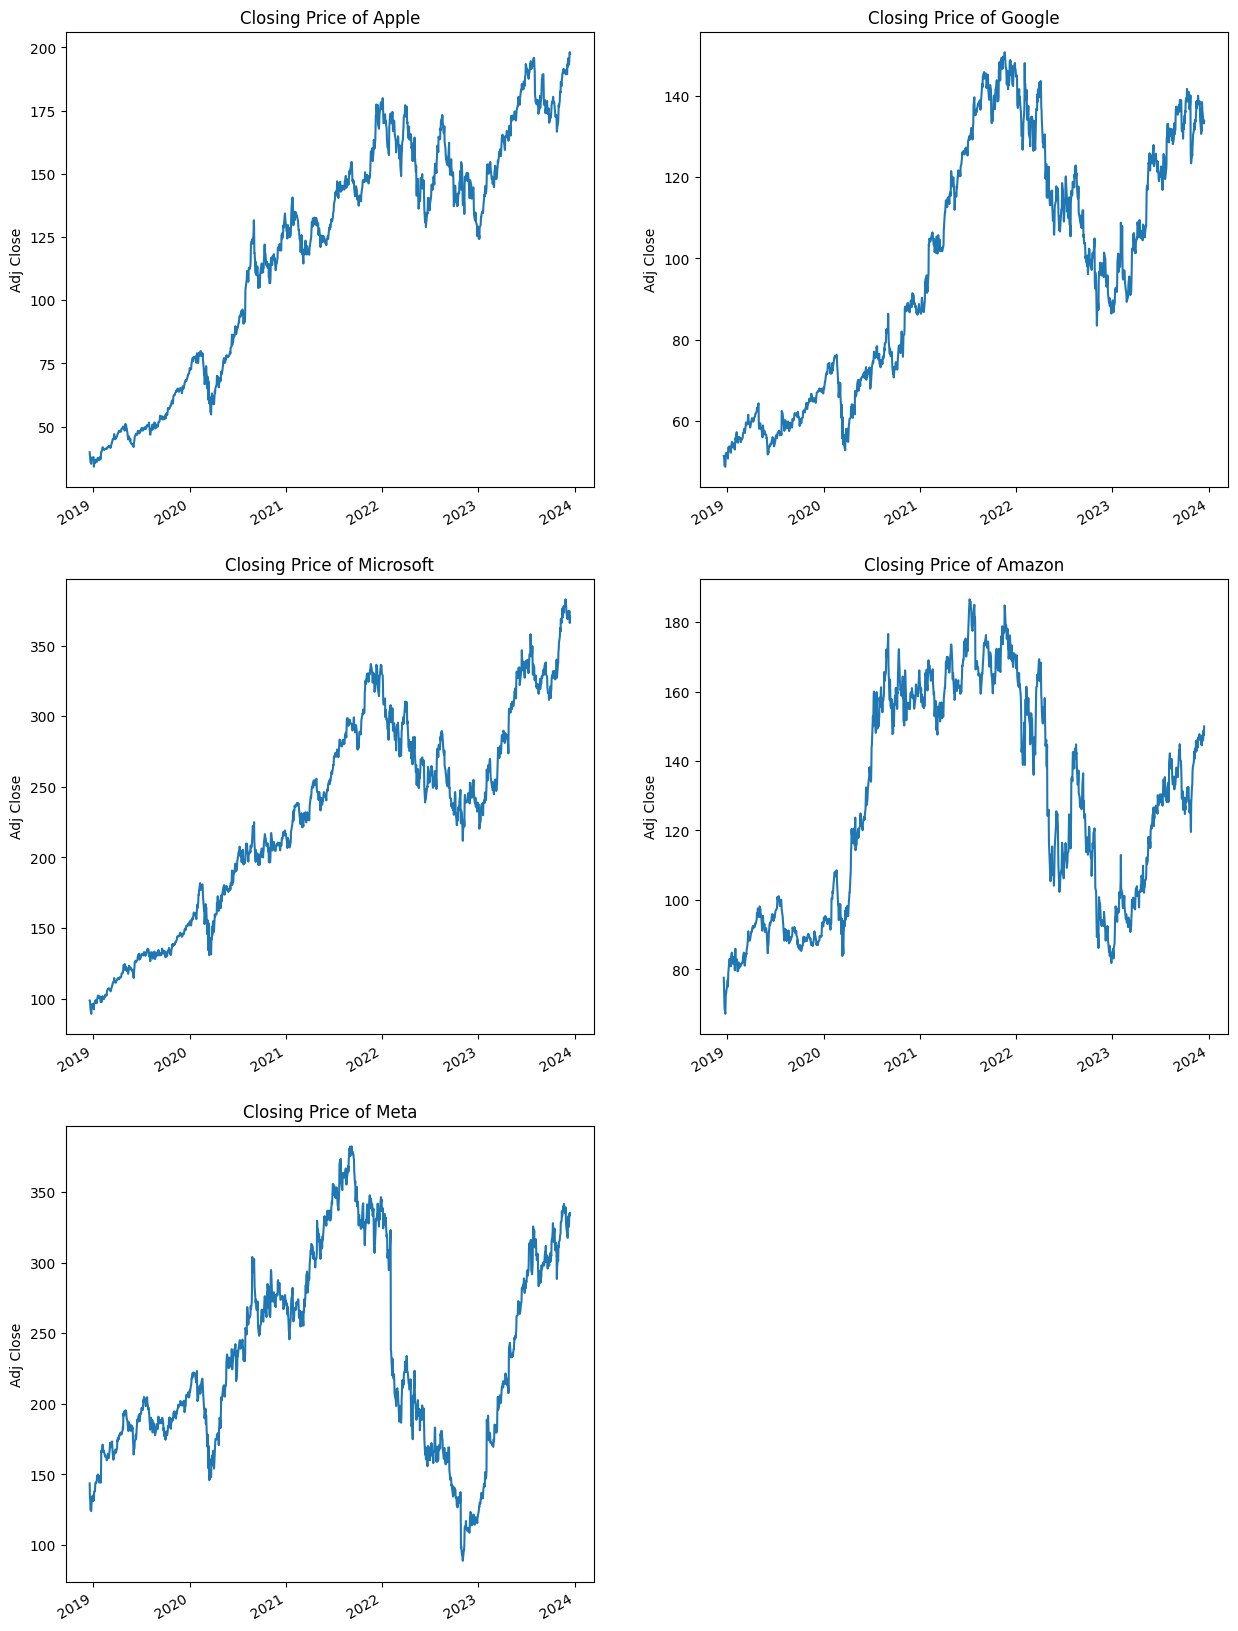

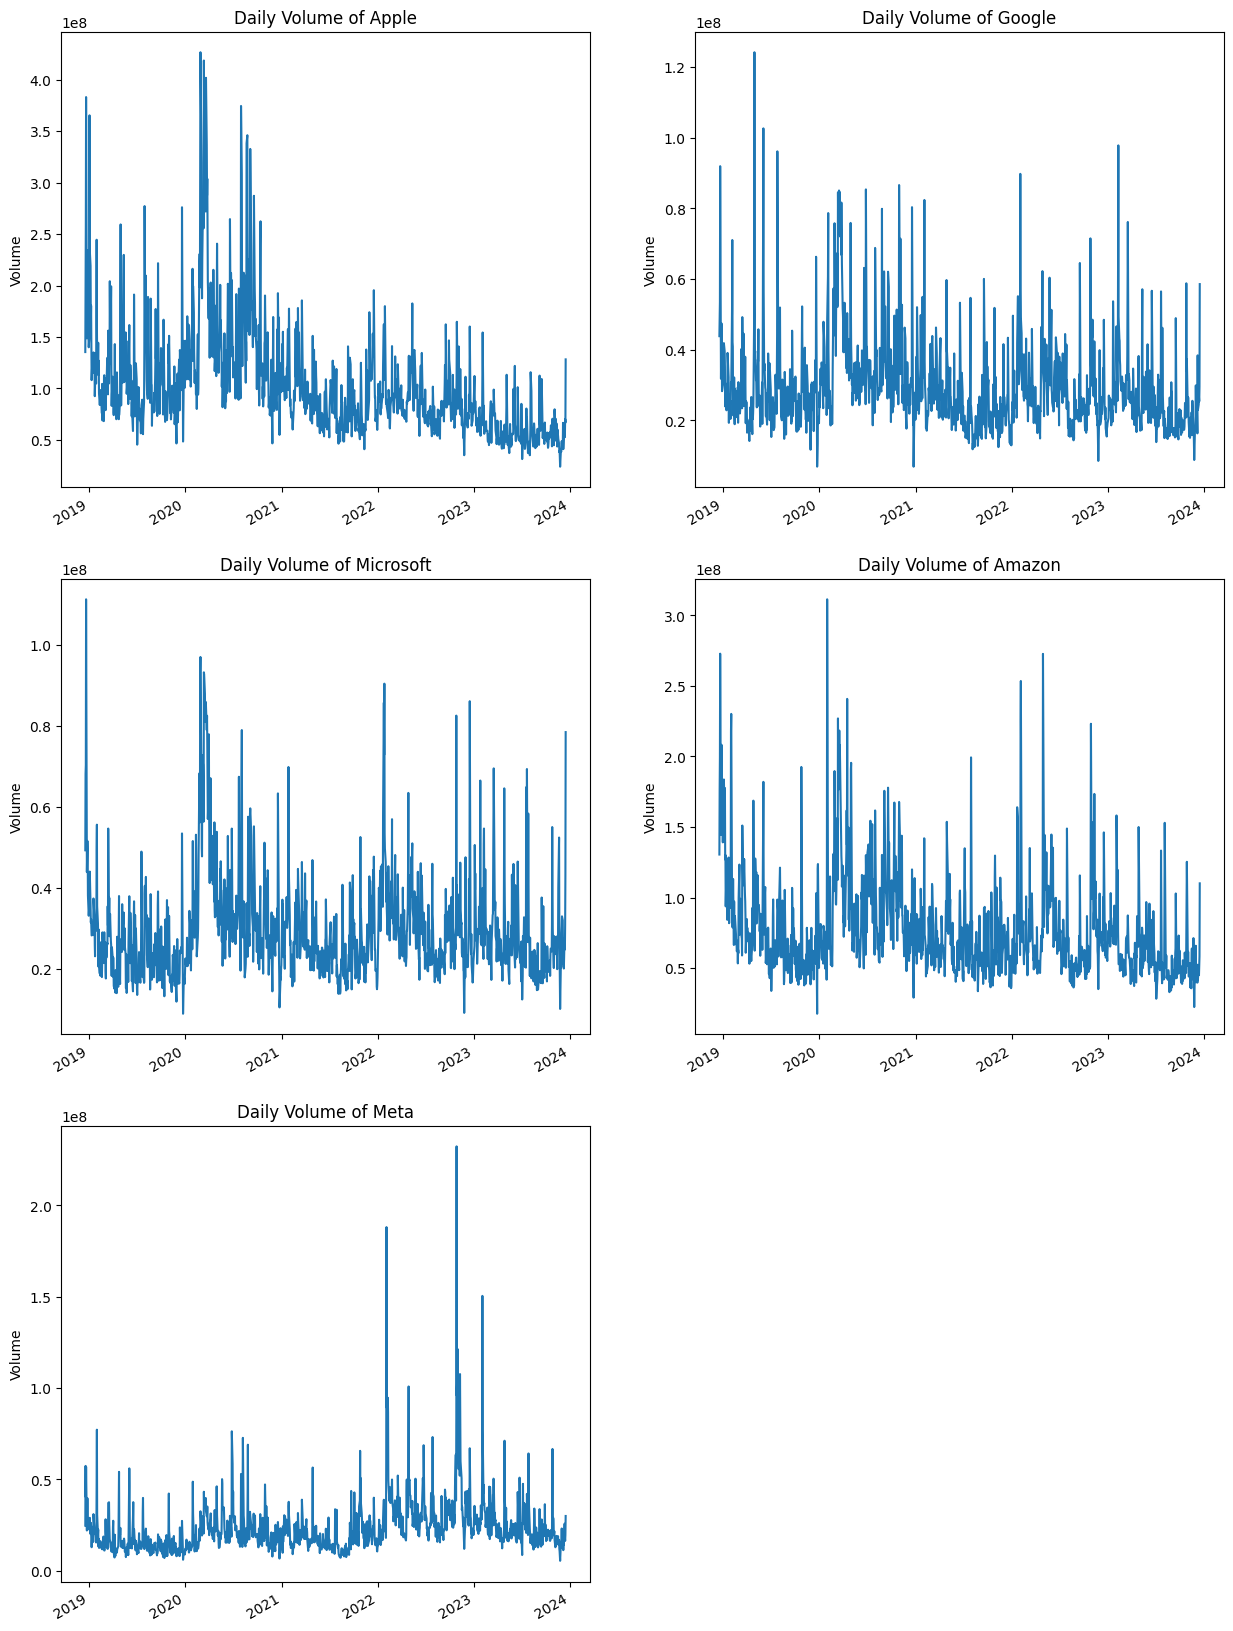

In [3]:
#plot closing price
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.75, bottom=1)

for i, company in enumerate(company_tickers):
    plt.subplot(3, 2, i+1)
    company['Adj Close'].plot()
    plt.ylabel('Adj Close')
    plt.xlabel(None)
    plt.title(f"Closing Price of {company_names[i]}")

#plot volumn
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.75, bottom=1)

for i, company in enumerate(company_tickers):
    plt.subplot(3, 2, i+1)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Daily Volume of {company_names[i]}")

<h1 align="left"><font color='blue'><font size = 2> 0.2 Moving Average for Certain Stocks</font></h1><a class='anchor' id='subsection2'></a>


Text(0.5, 1.0, 'Meta')

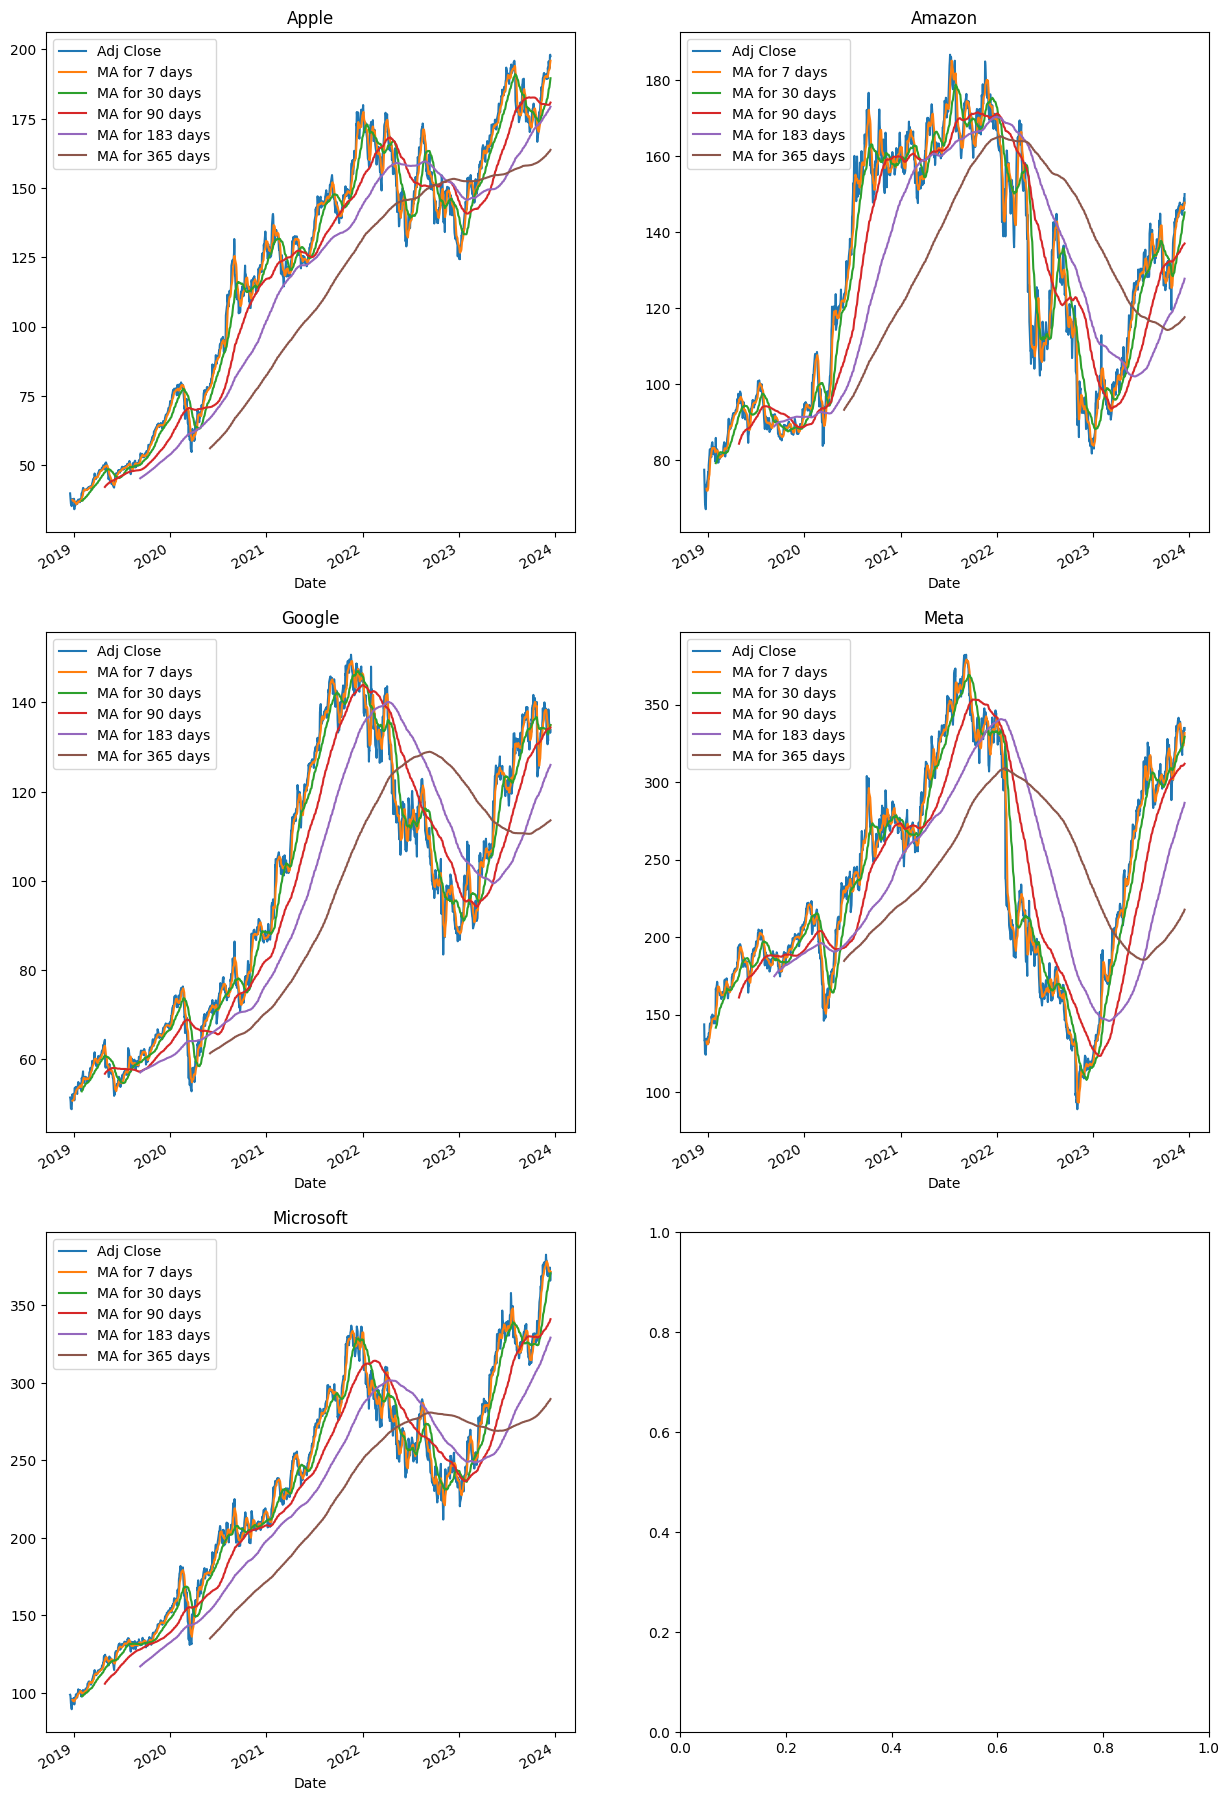

In [4]:
company_tickers=[AAPL,GOOG,MSFT,AMZN,META]

MA_days=[7,30,90,183,365]
for MA_day in MA_days:
    for company in company_tickers:
        column_name=f"MA for {MA_day} days"
        company[column_name]=company['Adj Close'].rolling(MA_day).mean()

fig, axes = plt.subplots(nrows=3, ncols=2)
fig.set_figheight(25) #set subplot hight
fig.set_figwidth(15) #set subplot width

AAPL[['Adj Close', 'MA for 7 days', 'MA for 30 days', 'MA for 90 days','MA for 183 days','MA for 365 days']].plot(ax=axes[0,0])
axes[0,0].set_title('Apple')

GOOG[['Adj Close', 'MA for 7 days', 'MA for 30 days', 'MA for 90 days','MA for 183 days','MA for 365 days']].plot(ax=axes[1,0])
axes[1,0].set_title('Google')

MSFT[['Adj Close', 'MA for 7 days', 'MA for 30 days', 'MA for 90 days','MA for 183 days','MA for 365 days']].plot(ax=axes[2,0])
axes[2,0].set_title('Microsoft')

AMZN[['Adj Close', 'MA for 7 days', 'MA for 30 days', 'MA for 90 days','MA for 183 days','MA for 365 days']].plot(ax=axes[0,1])
axes[0,1].set_title('Amazon')

META[['Adj Close', 'MA for 7 days', 'MA for 30 days', 'MA for 90 days','MA for 183 days','MA for 365 days']].plot(ax=axes[1,1])
axes[1,1].set_title('Meta')


<h1 align="left"><font color='blue'><font size = 2> 0.3 Average Daily Return in Certain Period</font></h1><a class='anchor' id='subsection3'></a>


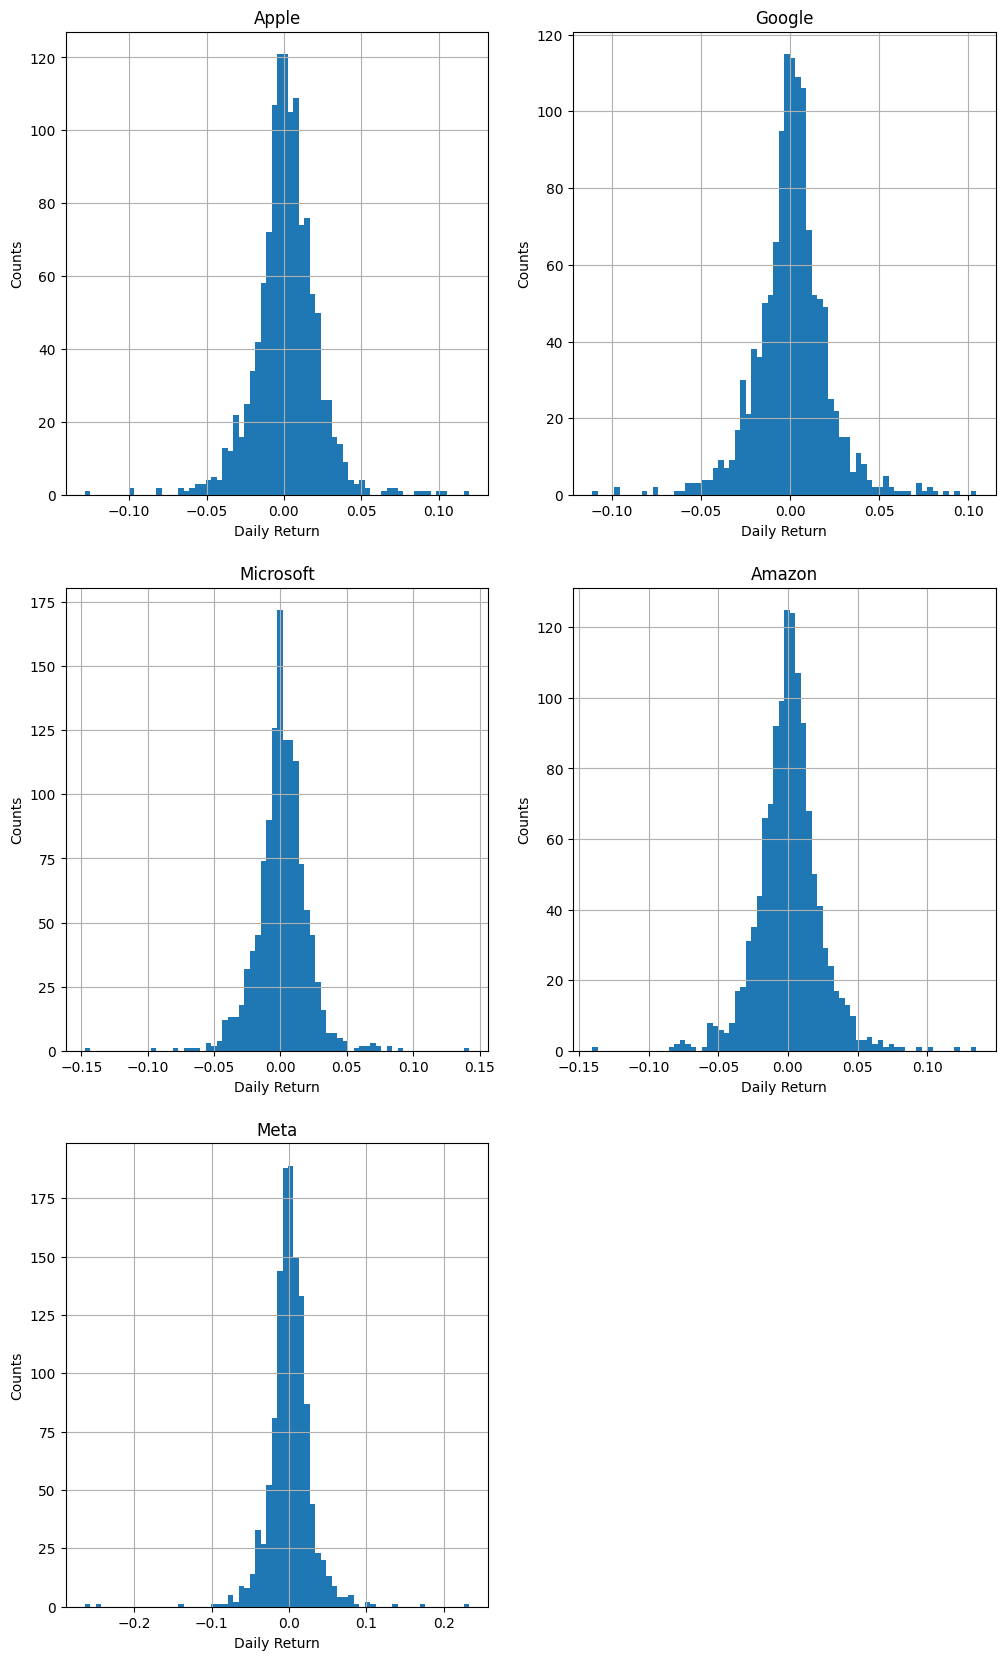

In [5]:
for company in company_tickers:
    company['Daily Return']=company['Adj Close'].pct_change()

plt.figure(figsize=(12, 9))
plt.subplots_adjust(top=2.75, bottom=1)

for i, company in enumerate(company_tickers):
    plt.subplot(3, 2, i+1)
    company['Daily Return'].hist(bins=70)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_names[i]}')

Correlations among different stocks

<Axes: >

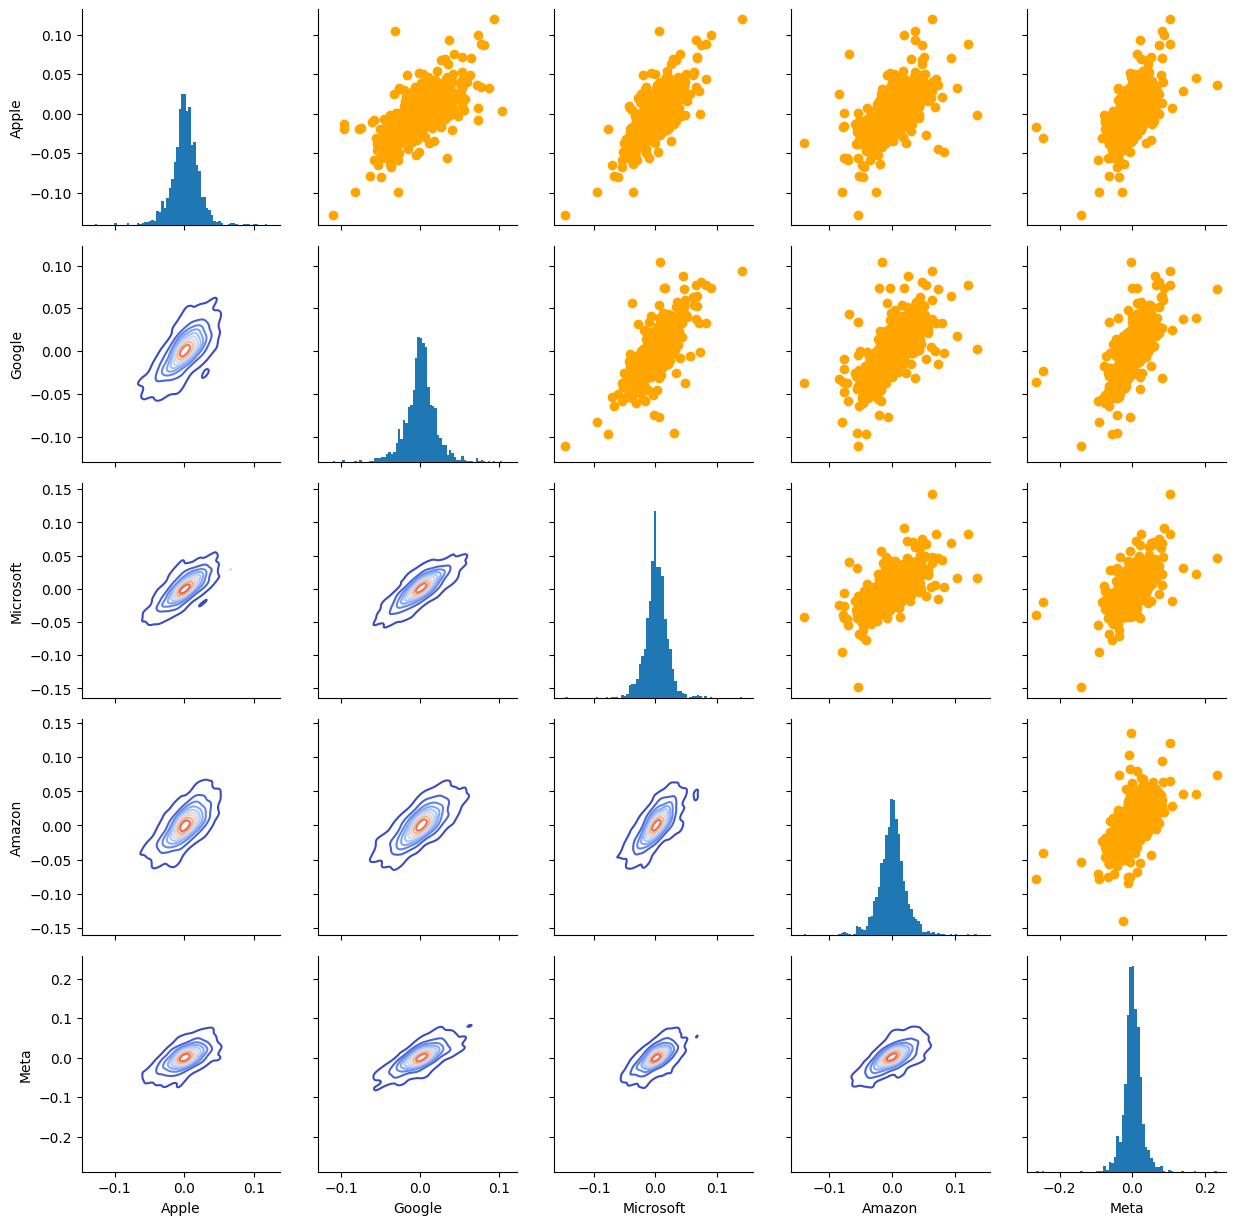

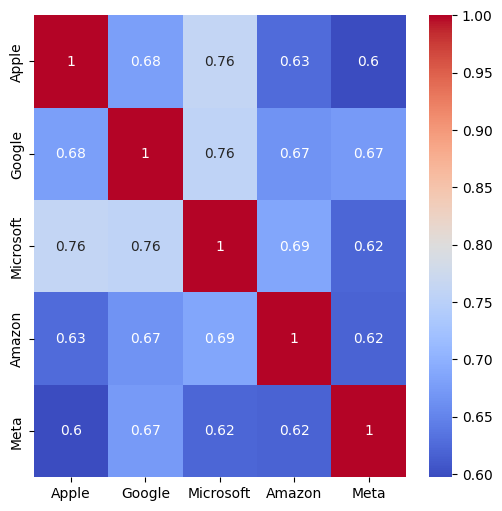

In [6]:
#Extract closing price into one dataframe
company_tickers=[AAPL,GOOG,MSFT,AMZN,META]
closing_df = pd.DataFrame()
for company in company_tickers:
    data=company['Adj Close']
    closing_df=pd.concat([closing_df,data],axis=1)
closing_df.columns.values[0]='Apple'
closing_df.columns.values[1]='Google'
closing_df.columns.values[2]='Microsoft'
closing_df.columns.values[3]='Amazon'
closing_df.columns.values[4]='Meta'
closing_df.head(3)

# Make a new df for returns
company_returns = closing_df.pct_change().iloc[1:,]
company_returns.head()

#plot correlations in return
return_fig = sns.PairGrid(company_returns.dropna())
return_fig.map_upper(plt.scatter, color='orange')
return_fig.map_lower(sns.kdeplot, cmap='coolwarm')
return_fig.map_diag(plt.hist, bins=70)

# #plot correlations in closing price
# return_fig = sns.PairGrid(closing_df.dropna())
# return_fig.map_upper(plt.scatter, color='orange')
# return_fig.map_lower(sns.kdeplot, cmap='coolwarm')
# return_fig.map_diag(plt.hist, bins=70)

#correlation heatmap of returns
plt.figure(figsize=(6, 6))
sns.heatmap(company_returns .corr(), annot=True, cmap='coolwarm')

<h1 align="left"><font color='blue'><font size = 2> 0.4 Risk and Shapie Value</font></h1><a class='anchor' id='subsection4'></a>

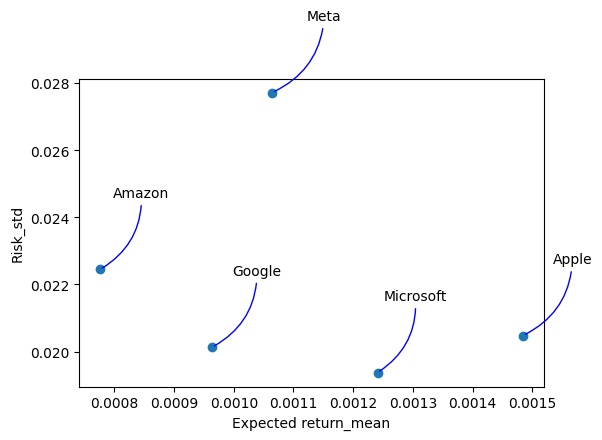

In [7]:
plt.figure(figsize=(6, 4))
plt.xlabel('Expected return_mean')
plt.ylabel('Risk_std')
plt.scatter(company_returns.mean(), company_returns.std())

for label, x, y in zip(company_returns.columns, company_returns.mean(), company_returns.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom', 
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

Predict future value, specifically Predicting High Price based on previous 'open','close' and 'low'

<h1 align="left"><font color='red'><font size=4>1. Linear Regression</font></h1><a class='anchor' id='section1'></a>
    


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt

import matplotlib.pyplot as plt

In [9]:
company_names=list(df['Company_names'].unique())
print(company_names)

# Dictionary to store the split datasets
split_data = {}

for company in company_names:
    company_data = df[df['Company_names'] == company]
    # Calculate the index for splitting and split the data
    split_index = int(0.7 * len(company_data))
    train_data = company_data.iloc[:split_index]
    test_data = company_data.iloc[split_index:]
    
    # Store the split datasets in the dictionary
    split_data[company + '_train'] = train_data
    split_data[company + '_test'] = test_data

# Create train and test data for each company
apple_train_data = split_data['Apple_train']
apple_test_data = split_data['Apple_test']
google_train_data = split_data['Google_train']
google_test_data = split_data['Google_test']
microsoft_train_data = split_data['Microsoft_train']
microsoft_test_data = split_data['Microsoft_test']
amazon_train_data = split_data['Amazon_train']
amazon_test_data = split_data['Amazon_test']
meta_train_data = split_data['Meta_train']
meta_test_data = split_data['Meta_test']
len(meta_train_data)

['Apple', 'Google', 'Microsoft', 'Amazon', 'Meta']


880



Performance metrics for Apple:

  Train Mean Squared Error (MSE): 2.6126886708301065

  Train Root Mean Squared Error (RMSE): 1.616381350681239

  Train R-squared: 0.9986559741005087

  Train Mean Absolute Error (MAE): 1.1331225903131268

  ------

  Test Mean Squared Error (MSE): 4.221747481246387

  Test Root Mean Squared Error (RMSE): 2.054689144675269

  Test R-squared: 0.9875506920760494

  Test Mean Absolute Error (MAE): 1.5315906627276854

  ---------------------------------------------



Performance metrics for Google:

  Train Mean Squared Error (MSE): 1.952572617912061

  Train Root Mean Squared Error (RMSE): 1.397344845738539

  Train R-squared: 0.9981705595460355

  Train Mean Absolute Error (MAE): 0.9027059259964108

  ------

  Test Mean Squared Error (MSE): 3.6764418547020195

  Test Root Mean Squared Error (RMSE): 1.9174049793150167

  Test R-squared: 0.9853112273946147

  Test Mean Absolute Error (MAE): 1.3440967317436197

  -----------------------------------------

,Coefficients,Intercept
Apple,"[-0.09188, 0.90793, 0.19991, 0.0]",-0.97457
Google,"[0.13319, 0.96352, -0.08737, 0.0]",-0.31356
Microsoft,"[0.03906, 0.7312, 0.24118, 0.0]",-1.89773
Amazon,"[-0.06085, 0.99143, 0.08361, 0.0]",-1.00785
Meta,"[-0.06666, 0.8779, 0.19597, 0.0]",1.10254


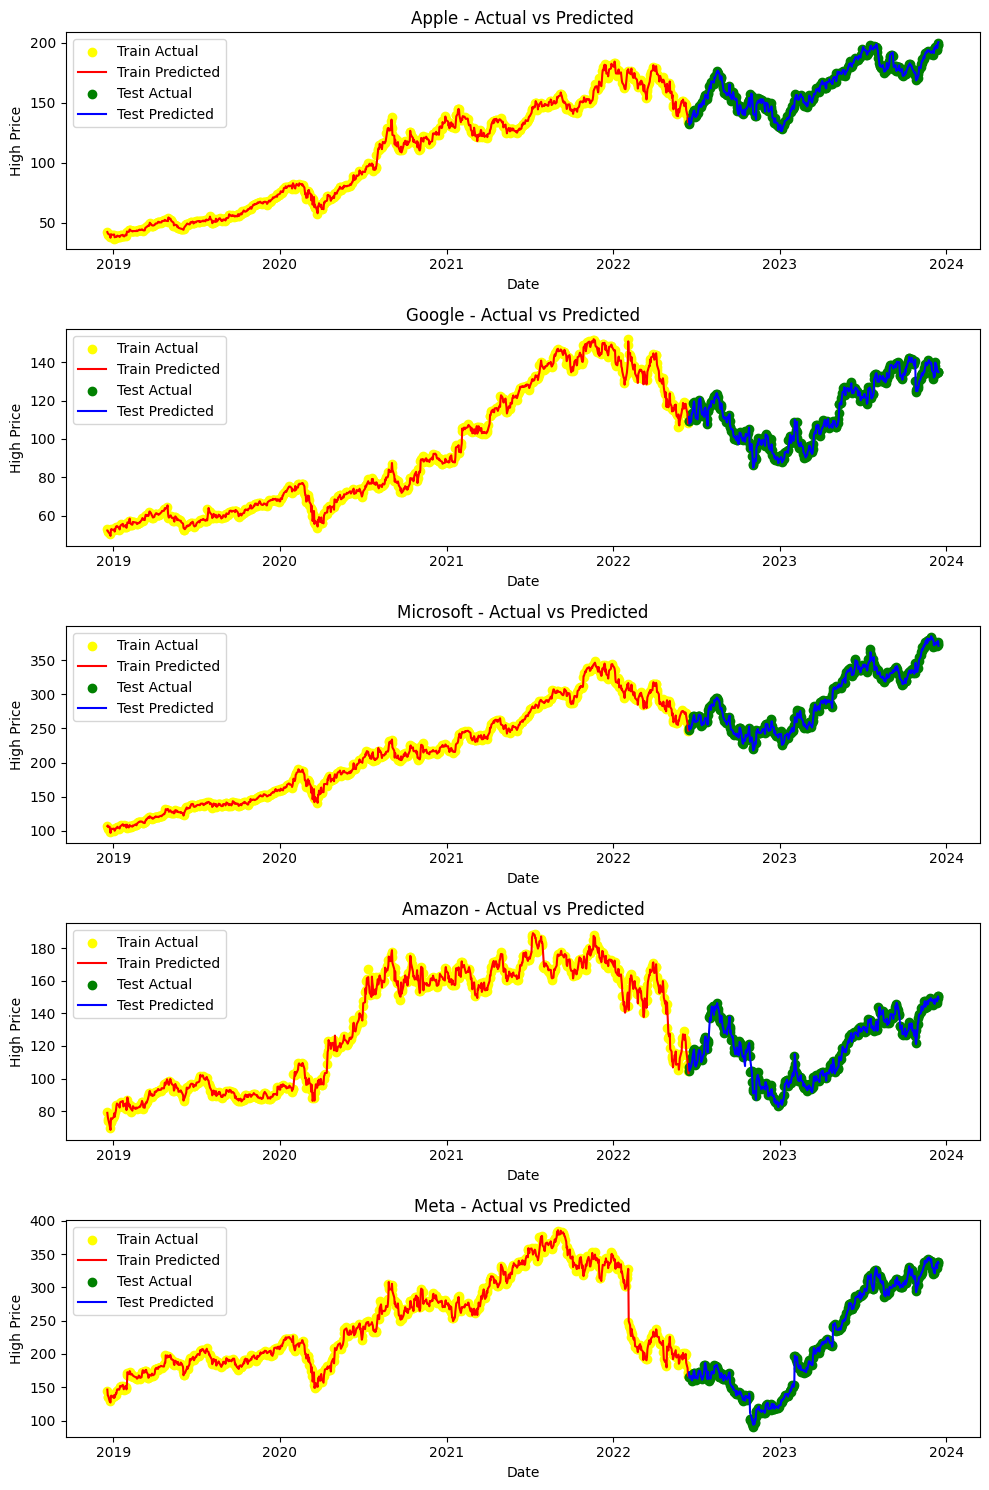

In [10]:
all_companies_data = df

# Dictionary to store coefficients and intercept for each company
coefficients_intercept = {}
fig, axes = plt.subplots(nrows=len(all_companies_data['Company_names'].unique()), ncols=1, figsize=(10, 15))

# Loop through each company
for i, company in enumerate(all_companies_data['Company_names'].unique()):
    company_data = all_companies_data[all_companies_data['Company_names'] == company]
    
    # Add lag features
    company_data_new = company_data.copy()
    for col in ['Open', 'Close', 'Low', 'Volume']:
        company_data_new.loc[:, f'{col}_prev'] = company_data.loc[:, col].shift(1)
    
    # Drop rows with NaN values introduced by shifting
    company_data_new = company_data_new.dropna()
    
    # Extracting features and target
    x = company_data_new[['Open_prev', 'Close_prev', 'Low_prev', 'Volume_prev']].values
    y_actual = company_data_new['High'].values

    # Splitting data into training (70%) and testing (30%)
    split_index = int(0.7 * len(x))
    x_train = x[:split_index,]
    x_test = x[split_index:,]
    y_train_actual = y_actual[:split_index,]
    y_test_actual = y_actual[split_index:,]
    
    # Creating and fitting the Linear Regression model
    model_lnr = LinearRegression()
    model_lnr.fit(x_train, y_train_actual)

    # Getting the coefficients and intercept
    coefficients = model_lnr.coef_
    intercept = model_lnr.intercept_
    rounded_coefficients = [round(coef, 5) for coef in coefficients]
    rounded_intercept = round(intercept, 5)
    coefficients_intercept[company] = {'Coefficients': rounded_coefficients, 'Intercept': rounded_intercept}

    # Predicting the target values
    y_train_predicted = model_lnr.predict(x_train)
    y_test_predicted = model_lnr.predict(x_test)

    # Evaluating the model performance for each company
    mse_train = mean_squared_error(y_train_actual, y_train_predicted)
    rmse_train = sqrt(mse_train)
    r2_train = r2_score(y_train_actual, y_train_predicted)
    mae_train = mean_absolute_error(y_train_actual, y_train_predicted)

    mse_test = mean_squared_error(y_test_actual, y_test_predicted)
    rmse_test = sqrt(mse_test)
    r2_test = r2_score(y_test_actual, y_test_predicted)
    mae_test = mean_absolute_error(y_test_actual, y_test_predicted)

    print(f"\nPerformance metrics for {company}:")
    print(f"  Train Mean Squared Error (MSE): {mse_train}")
    print(f"  Train Root Mean Squared Error (RMSE): {rmse_train}")
    print(f"  Train R-squared: {r2_train}")
    print(f"  Train Mean Absolute Error (MAE): {mae_train}")
    print('  ------')
    print(f"  Test Mean Squared Error (MSE): {mse_test}")
    print(f"  Test Root Mean Squared Error (RMSE): {rmse_test}")
    print(f"  Test R-squared: {r2_test}")
    print(f"  Test Mean Absolute Error (MAE): {mae_test}")
    print('  ---------------------------------------------')

    # Plotting training set
    axes[i].scatter(company_data_new.index[:split_index], y_train_actual, label='Train Actual', color='yellow',)
    axes[i].plot(company_data_new.index[:split_index], y_train_predicted, label='Train Predicted', color='red')

    # Plotting testing set
    axes[i].scatter(company_data_new.index[split_index:], y_test_actual, label='Test Actual', color='green')
    axes[i].plot(company_data_new.index[split_index:], y_test_predicted, label='Test Predicted', color='blue')

    axes[i].set_title(f'{company} - Actual vs Predicted')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('High Price')
    axes[i].legend()

# Displaying the coefficients and intercept for each company
print("\nCoefficients and Intercept for each company:")
display(pd.DataFrame.from_dict(coefficients_intercept, orient='index'))

plt.tight_layout()
plt.show()


<h1 align="left"><font color='red'><font size=4>2. ARIMA</font></h1><a class='anchor' id='section2'></a>

In [11]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt
import matplotlib.pyplot as plt


/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

  return get_prediction_index(

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

  return get_prediction_index(




Performance metrics for Apple:

  Train Mean Squared Error (MSE): 5.721306525655048

  Train Root Mean Squared Error (RMSE): 2.391925275934649

  Train R-squared: 0.9970568310586482

  Train Mean Absolute Error (MAE): 1.3574946037668665

  ------

  Test Mean Squared Error (MSE): 199.04568756965455

  Test Root Mean Squared Error (RMSE): 14.10835523970298

  Test R-squared: 0.4130437534464957

  Test Mean Absolute Error (MAE): 11.232116140127218

  ---------------------------------------------


/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

  return get_prediction_index(

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

  return get_prediction_index(




Performance metrics for Google:

  Train Mean Squared Error (MSE): 5.572425107407747

  Train Root Mean Squared Error (RMSE): 2.360598463823898

  Train R-squared: 0.9947789803950645

  Train Mean Absolute Error (MAE): 1.076371444677635

  ------

  Test Mean Squared Error (MSE): 255.43303952097688

  Test Root Mean Squared Error (RMSE): 15.98227266445473

  Test R-squared: -0.02055138683272517

  Test Mean Absolute Error (MAE): 13.974112735019588

  ---------------------------------------------


/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

  return get_prediction_index(

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

  return get_prediction_index(




Performance metrics for Microsoft:

  Train Mean Squared Error (MSE): 22.67724463554362

  Train Root Mean Squared Error (RMSE): 4.762063065053173

  Train R-squared: 0.9952844122308573

  Train Mean Absolute Error (MAE): 2.2770227100676226

  ------

  Test Mean Squared Error (MSE): 943.974962972627

  Test Root Mean Squared Error (RMSE): 30.724175545856834

  Test R-squared: 0.5123475802618116

  Test Mean Absolute Error (MAE): 26.405348642148677

  ---------------------------------------------


/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

  return get_prediction_index(

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

  return get_prediction_index(




Performance metrics for Amazon:

  Train Mean Squared Error (MSE): 13.46394833910679

  Train Root Mean Squared Error (RMSE): 3.6693253247847606

  Train R-squared: 0.9892020475332798

  Train Mean Absolute Error (MAE): 1.761353401079203

  ------

  Test Mean Squared Error (MSE): 419.1673319975441

  Test Root Mean Squared Error (RMSE): 20.473576433968347

  Test R-squared: -0.26719310023776366

  Test Mean Absolute Error (MAE): 17.71461051906704

  ---------------------------------------------


/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.

  return get_prediction_index(

/Users/enhongliu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

  return get_prediction_index(




Performance metrics for Meta:

  Train Mean Squared Error (MSE): 55.13755834900296

  Train Root Mean Squared Error (RMSE): 7.425466877510327

  Train R-squared: 0.9869221933294222

  Train Mean Absolute Error (MAE): 3.720682536918286

  ------

  Test Mean Squared Error (MSE): 8060.844237507677

  Test Root Mean Squared Error (RMSE): 89.78220445894429

  Test R-squared: -0.37180849262896754

  Test Mean Absolute Error (MAE): 71.12081911198045

  ---------------------------------------------


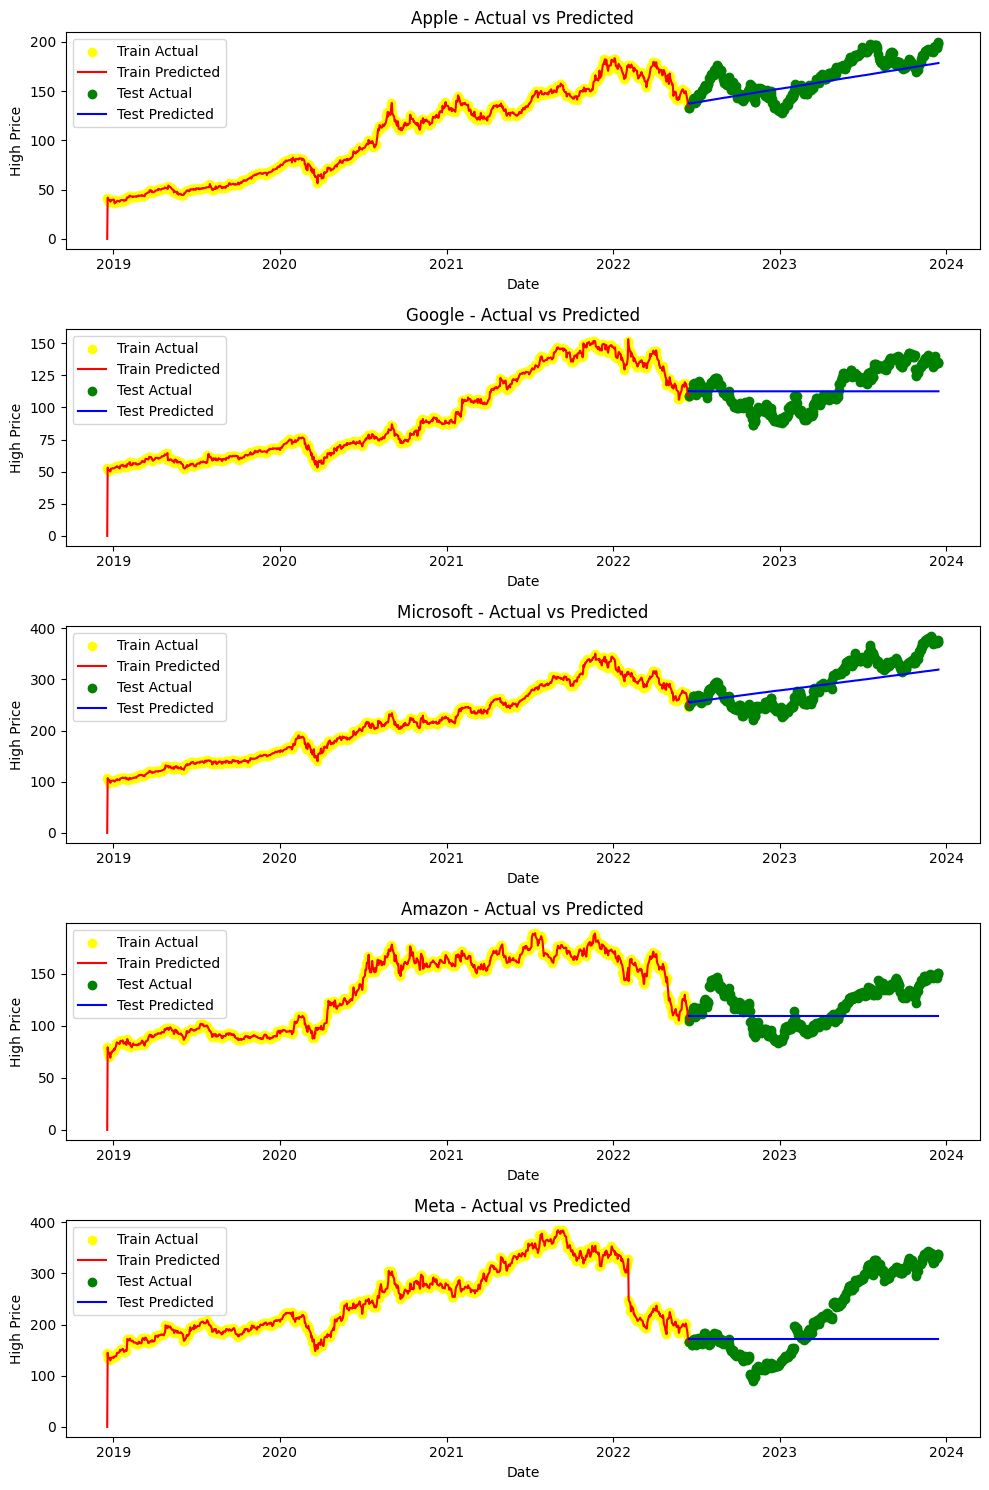

In [12]:
all_companies_data = df

# Dictionary to store coefficients and intercept for each company
coefficients_intercept = {}

# Plotting the results for each company
fig, axes = plt.subplots(nrows=len(all_companies_data['Company_names'].unique()), ncols=1, figsize=(10, 15))

# Loop through each company
for i, company in enumerate(all_companies_data['Company_names'].unique()):
    company_data = all_companies_data[all_companies_data['Company_names'] == company]
    
    # Add lag features using .loc
    company_data_new = company_data.copy()
    for col in ['Open', 'Close', 'Low', 'Volume']:
        company_data_new.loc[:, f'{col}_prev'] = company_data.loc[:, col].shift(1)
    
    # Drop rows with NaN values introduced by shifting
    company_data_new = company_data_new.dropna()
    
    # Extracting features and target
    y_actual = company_data_new['High']
    
    # Splitting data into training (70%) and testing (30%)
    split_index = int(0.7 * len(y_actual))
    y_train_actual = y_actual[:split_index]
    y_test_actual = y_actual[split_index:]
    
    # Using auto_arima to automatically select the best ARIMA parameters
    model_arima = auto_arima(y_train_actual, seasonal=True, suppress_warnings=True)

    # Forecasting
    y_train_predicted = model_arima.predict_in_sample()
    y_test_predicted = model_arima.predict(n_periods=len(y_test_actual))

    # Evaluating the model performance for each company
    mse_train = mean_squared_error(y_train_actual, y_train_predicted)
    rmse_train = sqrt(mse_train)
    r2_train = r2_score(y_train_actual, y_train_predicted)
    mae_train = mean_absolute_error(y_train_actual, y_train_predicted)

    mse_test = mean_squared_error(y_test_actual[:], y_test_predicted)
    rmse_test = sqrt(mse_test)
    r2_test = r2_score(y_test_actual[:], y_test_predicted)
    mae_test = mean_absolute_error(y_test_actual[:], y_test_predicted)

    print(f"\nPerformance metrics for {company}:")
    print(f"  Train Mean Squared Error (MSE): {mse_train}")
    print(f"  Train Root Mean Squared Error (RMSE): {rmse_train}")
    print(f"  Train R-squared: {r2_train}")
    print(f"  Train Mean Absolute Error (MAE): {mae_train}")
    print('  ------')
    print(f"  Test Mean Squared Error (MSE): {mse_test}")
    print(f"  Test Root Mean Squared Error (RMSE): {rmse_test}")
    print(f"  Test R-squared: {r2_test}")
    print(f"  Test Mean Absolute Error (MAE): {mae_test}")
    print('  ---------------------------------------------')

    # Plotting training set
    axes[i].scatter(company_data_new.index[:split_index], y_train_actual, label='Train Actual', color='yellow',)
    axes[i].plot(company_data_new.index[:split_index], y_train_predicted, label='Train Predicted', color='red')

    # Plotting testing set
    axes[i].scatter(company_data_new.index[split_index:], y_test_actual[:], label='Test Actual', color='green')
    axes[i].plot(company_data_new.index[split_index:], y_test_predicted, label='Test Predicted', color='blue')

    axes[i].set_title(f'{company} - Actual vs Predicted')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('High Price')
    axes[i].legend()

plt.tight_layout()
plt.show()


<h1 align="left"><font color='red'><font size=4>3. LSTM</font></h1><a class='anchor' id='section3'></a>

In [13]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler

880/880 [==============================] - 3s 1ms/step - loss: 0.0125

28/28 [==============================] - 1s 1ms/step

12/12 [==============================] - 0s 1ms/step



Performance metrics for Apple:

  Train Mean Squared Error (MSE): 2.9324905387153524

  Train Root Mean Squared Error (RMSE): 1.7124516164596746

  Train R-squared: 0.9984932886129131

  Train Mean Absolute Error (MAE): 1.519948625564575

  ------

  Test Mean Squared Error (MSE): 2.9367739681963547

  Test Root Mean Squared Error (RMSE): 1.713701831765478

  Test R-squared: 0.9913398886135357

  Test Mean Absolute Error (MAE): 1.4535463726709759

  ---------------------------------------------

880/880 [==============================] - 3s 2ms/step - loss: 0.0124

28/28 [==============================] - 1s 638us/step

12/12 [==============================] - 0s 790us/step



Performance metrics for Google:

  Train Mean Squared Error (MSE): 1.2771948823600972

  Train Root Mean Squared Error (RMSE): 1.1301

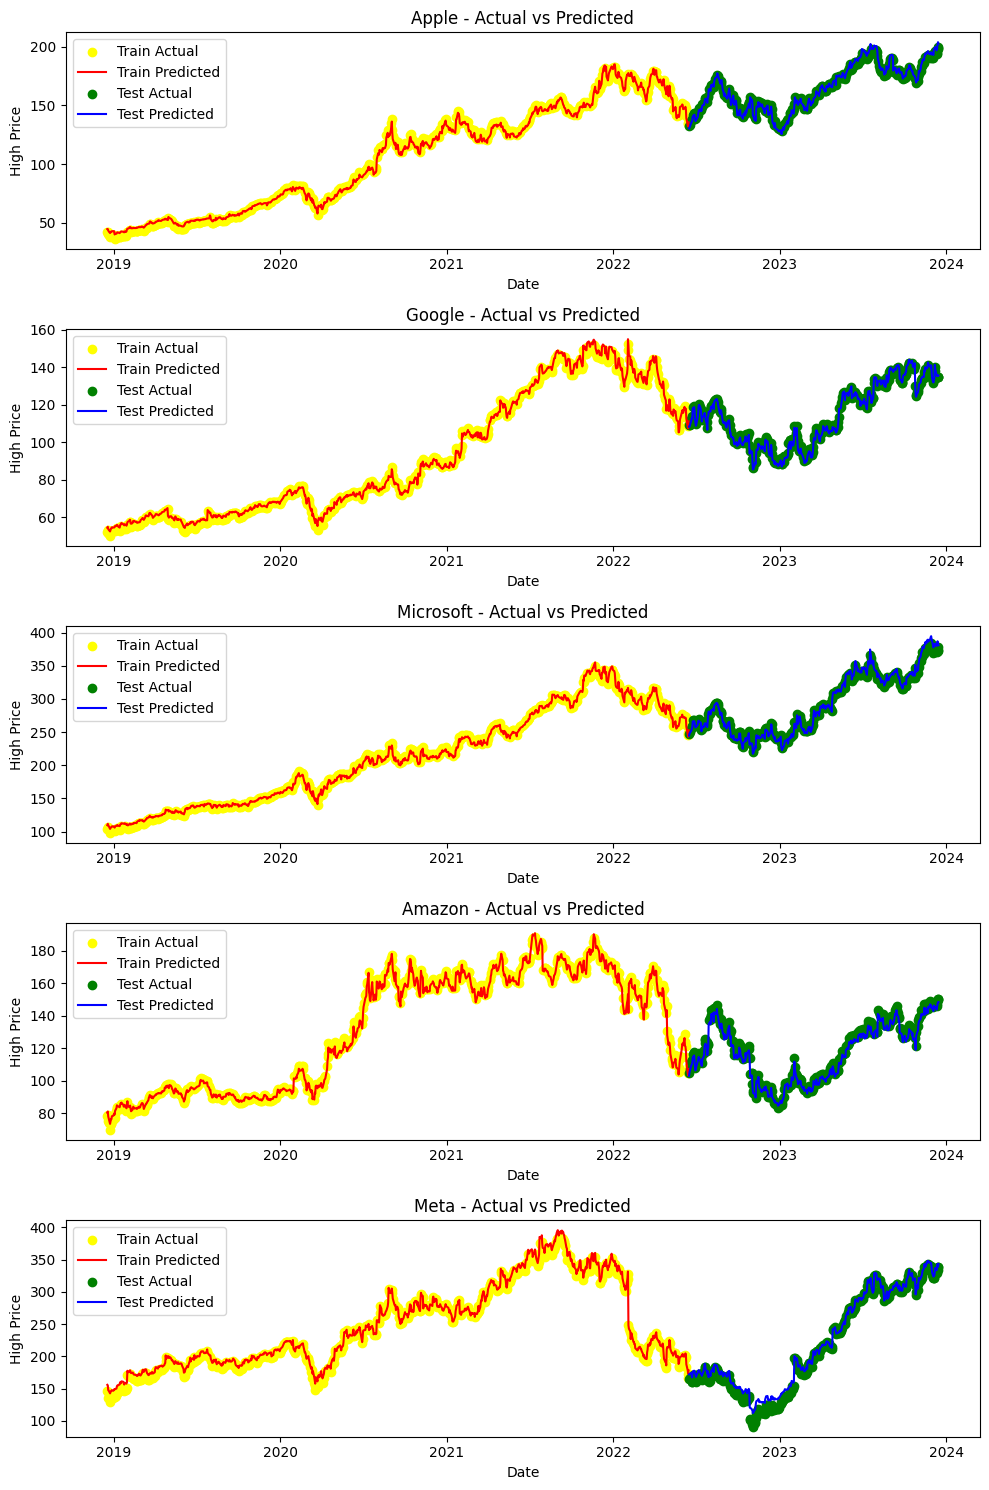

In [14]:
all_companies_data = df

# Dictionary to store coefficients and intercept for each company
coefficients_intercept = {}

# Plotting the results for each company
fig, axes = plt.subplots(nrows=len(all_companies_data['Company_names'].unique()), ncols=1, figsize=(10, 15))

# Loop through each company
for i, company in enumerate(all_companies_data['Company_names'].unique()):
    company_data = all_companies_data[all_companies_data['Company_names'] == company]
    
    # Extracting features and target
    y_actual = company_data.filter(['High'])
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_y_actual = scaler.fit_transform(y_actual.values)
    
    # Splitting data into training (70%) and testing (30%)
    split_index = int(0.7 * len(y_actual))
    y_train_actual = y_actual[:split_index]
    y_test_actual = y_actual[split_index:]
    scaled_y_train_actual = scaled_y_actual[:split_index]
    scaled_y_test_actual = scaled_y_actual[split_index:]

    # Split the data into x_train and y_train data sets
    x_train = []
    y_train = []
    time_step=15

    for j in range(len(scaled_y_train_actual)):
        x_train.append(scaled_y_train_actual[j:(j+1), 0])
        y_train.append(scaled_y_train_actual[j, 0])

    # Convert the x_train and y_train to numpy arrays 
    x_train, y_train = np.array(x_train), np.array(y_train)

    # Reshape the data
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Build the LSTM model
    tf.keras.backend.clear_session()
    model = Sequential()
    model.add(LSTM(32, return_sequences=True, input_shape= (x_train.shape[1], 1)))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Train the model
    model.fit(x_train, y_train, batch_size=1, epochs=1)
    
    # Create the testing data set
    x_test = []
    y_test = scaled_y_test_actual
    for k in range(len(scaled_y_test_actual)):
        x_test.append(scaled_y_test_actual[k:(k+1), 0])
    
    # Convert the data to a numpy array
    x_test = np.array(x_test)

    # Reshape the data
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

    # Get the models predicted price values
    y_train_predicted = model.predict(x_train)
    y_test_predicted = model.predict(x_test)

    # Inverse transform the predictions to the original scale
    y_train_predicted = scaler.inverse_transform(y_train_predicted)
    y_test_predicted = scaler.inverse_transform(y_test_predicted)

    # Evaluating the model performance for each company
    mse_train = mean_squared_error(y_train_actual, y_train_predicted)
    rmse_train = sqrt(mse_train)
    r2_train = r2_score(y_train_actual, y_train_predicted)
    mae_train = mean_absolute_error(y_train_actual, y_train_predicted)

    mse_test = mean_squared_error(y_test_actual, y_test_predicted)
    rmse_test = sqrt(mse_test)
    r2_test = r2_score(y_test_actual, y_test_predicted)
    mae_test = mean_absolute_error(y_test_actual, y_test_predicted)

    print(f"\nPerformance metrics for {company}:")
    print(f"  Train Mean Squared Error (MSE): {mse_train}")
    print(f"  Train Root Mean Squared Error (RMSE): {rmse_train}")
    print(f"  Train R-squared: {r2_train}")
    print(f"  Train Mean Absolute Error (MAE): {mae_train}")
    print('  ------')
    print(f"  Test Mean Squared Error (MSE): {mse_test}")
    print(f"  Test Root Mean Squared Error (RMSE): {rmse_test}")
    print(f"  Test R-squared: {r2_test}")
    print(f"  Test Mean Absolute Error (MAE): {mae_test}")
    print('  ---------------------------------------------')

    # Plotting training set
    axes[i].scatter(company_data.index[:split_index], y_train_actual, label='Train Actual', color='yellow',)
    axes[i].plot(company_data.index[:split_index], y_train_predicted, label='Train Predicted', color='red')

    # Plotting testing set
    axes[i].scatter(company_data.index[split_index:], y_test_actual, label='Test Actual', color='green')
    axes[i].plot(company_data.index[split_index:], y_test_predicted, label='Test Predicted', color='blue')

    axes[i].set_title(f'{company} - Actual vs Predicted')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('High Price')
    axes[i].legend()




plt.tight_layout()
plt.show()


<h1 align="left"><font color='red'><font size=4>4. LSTM + GRU</font></h1><a class='anchor' id='section4'></a>

In [20]:
from tensorflow.keras.layers import LSTM, GRU

880/880 [==============================] - 5s 3ms/step - loss: 0.0164

28/28 [==============================] - 1s 3ms/step

12/12 [==============================] - 0s 3ms/step



Performance metrics for Apple:

  Train Mean Squared Error (MSE): 4.717379291798732

  Train Root Mean Squared Error (RMSE): 2.1719528751330524

  Train R-squared: 0.997576214142101

  Train Mean Absolute Error (MAE): 1.8770410320975564

  ------

  Test Mean Squared Error (MSE): 14.569626975684148

  Test Root Mean Squared Error (RMSE): 3.817018073795846

  Test R-squared: 0.9570363283538126

  Test Mean Absolute Error (MAE): 2.9463064607489047

  ---------------------------------------------

880/880 [==============================] - 4s 2ms/step - loss: 0.0191

28/28 [==============================] - 1s 743us/step

12/12 [==============================] - 0s 3ms/step



Performance metrics for Google:

  Train Mean Squared Error (MSE): 3.321056448923975

  Train Root Mean Squared Error (RMSE): 1.82237659

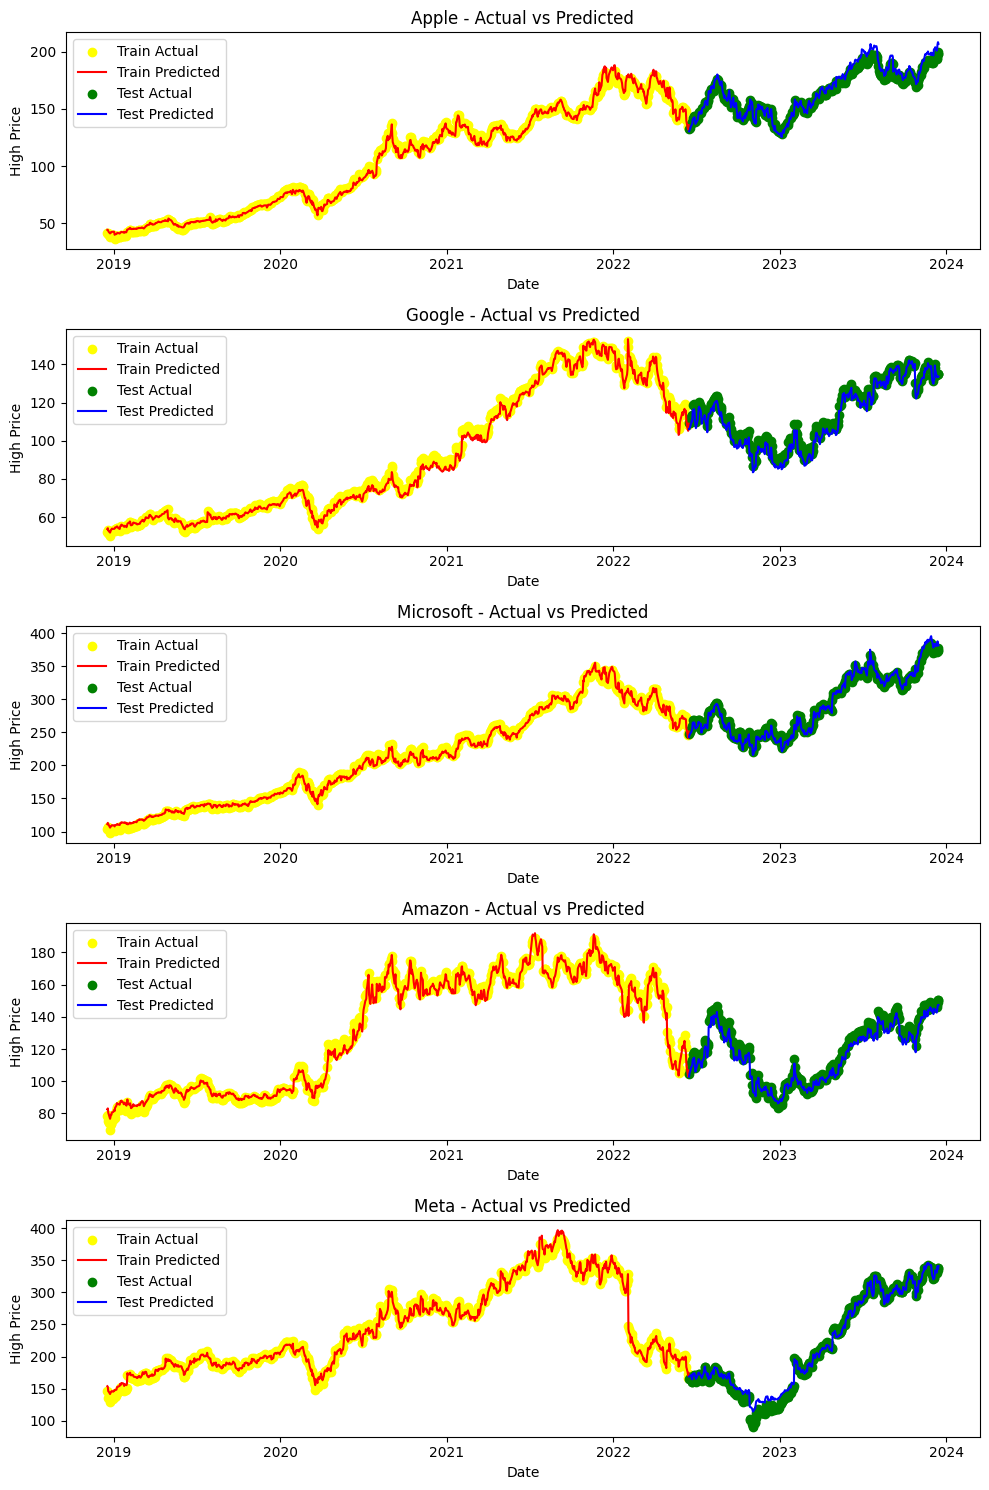

In [16]:
all_companies_data = df

# Dictionary to store coefficients and intercept for each company
coefficients_intercept = {}

# Plotting the results for each company
fig, axes = plt.subplots(nrows=len(all_companies_data['Company_names'].unique()), ncols=1, figsize=(10, 15))

# Loop through each company
for i, company in enumerate(all_companies_data['Company_names'].unique()):
    company_data = all_companies_data[all_companies_data['Company_names'] == company]
    
    # Extracting features and target
    y_actual = company_data.filter(['High'])
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_y_actual = scaler.fit_transform(y_actual.values)
    
    # Splitting data into training (70%) and testing (30%)
    split_index = int(0.7 * len(y_actual))
    y_train_actual = y_actual[:split_index]
    y_test_actual = y_actual[split_index:]
    scaled_y_train_actual = scaled_y_actual[:split_index]
    scaled_y_test_actual = scaled_y_actual[split_index:]

    # Split the data into x_train and y_train data sets
    x_train = []
    y_train = []
    time_step=15

    for j in range(len(scaled_y_train_actual)):
        x_train.append(scaled_y_train_actual[j:(j+1), 0])
        y_train.append(scaled_y_train_actual[j, 0])

    # Convert the x_train and y_train to numpy arrays 
    x_train, y_train = np.array(x_train), np.array(y_train)

    # Reshape the data
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Build the LSTM model
    tf.keras.backend.clear_session()
    model = Sequential()
    model.add(LSTM(32, return_sequences=True, input_shape= (x_train.shape[1], 1)))
    model.add(LSTM(32, return_sequences=True))
    model.add(GRU(32,return_sequences=False))
    # model.add(Dense(25))
    model.add(Dense(1))
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Train the model
    model.fit(x_train, y_train, batch_size=1, epochs=1)
    
    # Create the testing data set
    x_test = []
    y_test = scaled_y_test_actual
    for k in range(len(scaled_y_test_actual)):
        x_test.append(scaled_y_test_actual[k:(k+1), 0])
    
    # Convert the data to a numpy array
    x_test = np.array(x_test)

    # Reshape the data
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

    # Get the models predicted price values
    y_train_predicted = model.predict(x_train)
    y_test_predicted = model.predict(x_test)

    # Inverse transform the predictions to the original scale
    y_train_predicted = scaler.inverse_transform(y_train_predicted)
    y_test_predicted = scaler.inverse_transform(y_test_predicted)

    # Evaluating the model performance for each company
    mse_train = mean_squared_error(y_train_actual, y_train_predicted)
    rmse_train = sqrt(mse_train)
    r2_train = r2_score(y_train_actual, y_train_predicted)
    mae_train = mean_absolute_error(y_train_actual, y_train_predicted)

    mse_test = mean_squared_error(y_test_actual, y_test_predicted)
    rmse_test = sqrt(mse_test)
    r2_test = r2_score(y_test_actual, y_test_predicted)
    mae_test = mean_absolute_error(y_test_actual, y_test_predicted)

    print(f"\nPerformance metrics for {company}:")
    print(f"  Train Mean Squared Error (MSE): {mse_train}")
    print(f"  Train Root Mean Squared Error (RMSE): {rmse_train}")
    print(f"  Train R-squared: {r2_train}")
    print(f"  Train Mean Absolute Error (MAE): {mae_train}")
    print('  ------')
    print(f"  Test Mean Squared Error (MSE): {mse_test}")
    print(f"  Test Root Mean Squared Error (RMSE): {rmse_test}")
    print(f"  Test R-squared: {r2_test}")
    print(f"  Test Mean Absolute Error (MAE): {mae_test}")
    print('  ---------------------------------------------')

    # Plotting training set
    axes[i].scatter(company_data.index[:split_index], y_train_actual, label='Train Actual', color='yellow')
    axes[i].plot(company_data.index[:split_index], y_train_predicted, label='Train Predicted', color='red')

    # Plotting testing set
    axes[i].scatter(company_data.index[split_index:], y_test_actual, label='Test Actual', color='green')
    axes[i].plot(company_data.index[split_index:], y_test_predicted, label='Test Predicted', color='blue')

    axes[i].set_title(f'{company} - Actual vs Predicted')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('High Price')
    axes[i].legend()

plt.tight_layout()
plt.show()


             LSTM method can be a failture: https://www.kaggle.com/code/carlmcbrideellis/lstm-time-series-stock-price-prediction-fail/notebook 

<h1 align="left"><font color='red'><font size=4>5. B-Spline</font></h1><a class='anchor' id='section5'></a>

In [39]:
from scipy.interpolate import BSpline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt

In [19]:
def BSplineBasis(x: np.array, knots: np.array, degree: int) -> np.array:
    '''Return B-Spline basis. Python equivalent to bs in R or the spmak/spval combination in MATLAB.
    This function acts like the R command bs(x,knots=knots,degree=degree, intercept=False)
    Arguments:
        x: Points to evaluate spline on, sorted increasing
        knots: Spline knots, sorted increasing
        degree: Spline degree. 
    Returns:
        B: Array of shape (x.shape[0], len(knots)+degree+1). 
    Note that a spline has len(knots)+degree coefficients. However, because the intercept is missing 
    you will need to remove the last 2 columns. It's being kept this way to retain compatibility with
    both the matlab spmak way and how R's bs works.

    If K = length(knots) (includes boundary knots)
    Mapping this to R's bs: (Props to Nate Bartlett )
    bs(x,knots,degree,intercept=T)[,2:K+degree] is same as BSplineBasis(x,knots,degree)[:,:-2]
    BF = bs(x,knots,degree,intercept=F) drops the first column so BF[,1:K+degree] == BSplineBasis(x,knots,degree)[:,:-2]
    '''
    nKnots = knots.shape[0]
    lo = min(x[0], knots[0])
    hi = max(x[-1], knots[-1])
    augmented_knots = np.append(
        np.append([lo]*degree, knots), [hi]*degree)
    DOF = nKnots + degree +1 # DOF = K+M, M = degree+1
    spline = BSpline(augmented_knots, np.eye(DOF),
                     degree, extrapolate=False)
    B = spline(x)
    return B


In [23]:
df.head(3)

,Open,High,Low,Close,Adj Close,Volume,Company_names
Date,,,,,,,
2018-12-18,41.345001,41.882500,41.097500,41.517502,39.848949,135366000,Apple
2018-12-19,41.500000,41.862499,39.772499,40.222500,38.605991,196189200,Apple
2018-12-20,40.099998,40.527500,38.825001,39.207500,37.631783,259092000,Apple




Performance metrics for Apple:

  Test Mean Squared Error (MSE): 0.7403828953060416

  Train Mean Squared Error (MSE): 2.902089307419488

  Train Root Mean Squared Error (RMSE): 1.703551967924515

  Train R-squared: 0.9986895759937412

  Train Mean Absolute Error (MAE): 1.2355598781185166



Performance metrics for Google:

  Test Mean Squared Error (MSE): 0.4256512632918759

  Train Mean Squared Error (MSE): 2.0885039799349516

  Train Root Mean Squared Error (RMSE): 1.4451657274980443

  Train R-squared: 0.9977511869936488

  Train Mean Absolute Error (MAE): 1.060878003151268



Performance metrics for Microsoft:

  Test Mean Squared Error (MSE): 1.7634294100682575

  Train Mean Squared Error (MSE): 8.76225549731076

  Train Root Mean Squared Error (RMSE): 2.9601107238261815

  Train R-squared: 0.9983532469768444

  Train Mean Absolute Error (MAE): 2.166501579859573



Performance metrics for Amazon:

  Test Mean Squared Error (MSE): 0.9623539104163873

  Train Mean Squared Error (

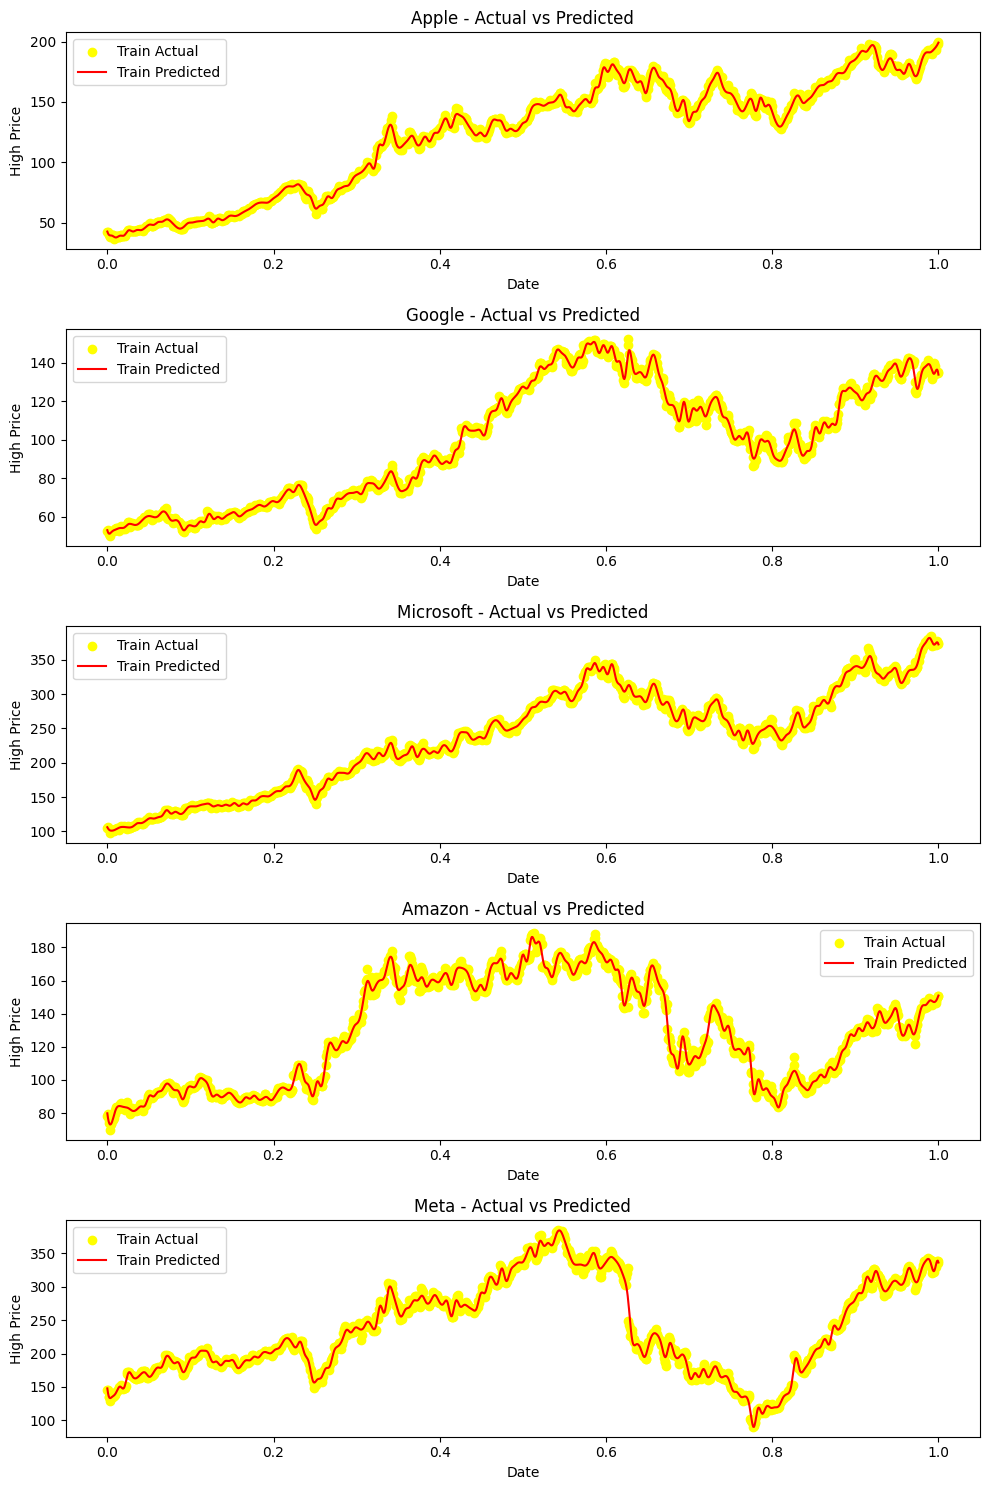

In [41]:
all_companies_data = df
# Plotting the results for each company
fig, axes = plt.subplots(nrows=len(all_companies_data['Company_names'].unique()), ncols=1, figsize=(10, 15))

# Loop through each company
for i, company in enumerate(all_companies_data['Company_names'].unique()):
    company_data = all_companies_data[all_companies_data['Company_names'] == company]
    y_actual = company_data.filter(['High']).values.reshape(1,-1)

    # 5fold cross validation to determine number of knots
    n = y_actual.shape[1] #num of measures
    X = np.linspace(0, 1, n)
    Y = y_actual.mean(0)
    mean_mses=[]

    for nknots in range(5,200):
        k=np.linspace(0, 1, nknots)
        kf = KFold(n_splits=5, random_state=42, shuffle=True)
        mse_scores = []

    # Perform 5-fold cross-validation
        for train_index, test_index in kf.split(X):
            X_train, X_test = X[train_index], X[test_index]
            Y_train, Y_test = Y[train_index], Y[test_index]
        # Calculate B from Training Data
            B = BSplineBasis(X, k, degree=3)[:,:-2]
            Bcoef = np.linalg.lstsq(B, X.T,rcond=None)[0].T
        # Make predictions using test data based on B
            yhat_test = B[test_index]@np.linalg.lstsq(B[test_index], Y_test,rcond=None)[0]
        # Calculate MSE for this fold
            mse = mean_squared_error(Y_test, yhat_test)
            mse_scores.append(mse)

    # Calculate the mean MSE across all folds and append it to the final list
        mean_mse = np.mean(mse_scores)
        mean_mses.append(mean_mse)

    lowest_mse = min(mean_mses)
    lowest_index = mean_mses.index(lowest_mse)
    lowest_mse_nknots=np.arange(5,200)[lowest_index]

    print(f"\nPerformance metrics for {company}:")
    print(f"  Test Mean Squared Error (MSE): {lowest_mse}")

    # Run B-spline with optimal nknots
    nknots=lowest_mse_nknots
    knots = np.linspace(0, 1, nknots)
    n = y_actual.shape[1] #num of measure
    x = np.linspace(0, 1, n)

    nMeasure=y_actual.shape[1]
    X= np.linspace(0, 1, nMeasure)

    B = BSplineBasis(x, knots, degree=3)[:,:-2]
    Bcoef = np.linalg.lstsq(B, X.T,rcond=None)[0].T

    B_stacked = np.tile(B.T, y_actual.shape[0]).T
    X_stacked = y_actual.ravel()
    beta = np.linalg.lstsq(B_stacked, X_stacked,rcond=None)[0]
    mu_hat = B.dot(beta)  # Mean function via B-Spline

    # Print results
    mse_train = mean_squared_error(y_actual, mu_hat.reshape(1,-1))
    rmse_train = sqrt(mse_train)
    r2_train = r2_score(y_actual.reshape(-1,1), mu_hat)
    mae_train = mean_absolute_error(y_actual, mu_hat.reshape(1,-1))
    print(f"  Train Mean Squared Error (MSE): {mse_train}")
    print(f"  Train Root Mean Squared Error (RMSE): {rmse_train}")
    print(f"  Train R-squared: {r2_train}")
    print(f"  Train Mean Absolute Error (MAE): {mae_train}")

    # Plot results
    axes[i].scatter(x, y_actual, label='Train Actual', color='yellow')
    axes[i].plot(x, mu_hat, label='Train Predicted', color='red')

    axes[i].set_title(f'{company} - Actual vs Predicted')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('High Price')
    axes[i].legend()

plt.tight_layout()
plt.show()

<h1 align="left"><font color='red'><font size=4>6. Future Work </font></h1><a class='anchor' id='section6'></a>

MCMC- Markov Chain Monte Carlo: https://www.kaggle.com/code/prashant111/tutorial-time-series-forecasting-with-prophet

Reinforcement learning:       https://www.kaggle.com/code/itoeiji/deep-reinforcement-learning-on-stock-data/comments